# Day 23 — Portfolio Optimization

## Objectives
- Calculate annualized expected returns and covariance
- Simulate portfolio allocations
- Plot the efficient frontier
- Calculate minimum-variance and maximum-Sharpe portfolios

Assets: AAPL, BLK, GS, JPM, MSFT
Constraints: Long-only, fully invested


In [5]:

import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

conn = sqlite3.connect("hedge_fund.db")

prices = pd.read_sql_query("""
SELECT date, ticker, close_price
FROM daily_prices
WHERE ticker IN ('AAPL', 'BLK', 'GS', 'JPM', 'MSFT')
ORDER BY date, ticker
""", conn)

prices["date"] = pd.to_datetime(prices["date"])

price_matrix = prices.pivot(
    index="date",
    columns="ticker",
    values="close_price"
).sort_index()

if price_matrix.isna().any().any():
    raise ValueError("Missing historical prices.")

returns = price_matrix.pct_change().dropna()

expected_returns = returns.mean() * 252
covariance = returns.cov() * 252

print("Annualized historical mean returns:")
display(expected_returns.to_frame("Expected Return"))

print("Annualized covariance matrix:")
display(covariance)


Annualized historical mean returns:


,Expected Return
ticker,
AAPL,0.324530
BLK,0.021315
GS,0.247301
JPM,0.163667
MSFT,0.045343


Annualized covariance matrix:


ticker,AAPL,BLK,GS,JPM,MSFT
ticker,,,,,
AAPL,0.060481,0.019496,0.017427,0.009869,0.010036
BLK,0.019496,0.075657,0.047536,0.028355,0.018231
GS,0.017427,0.047536,0.103836,0.045299,0.015960
JPM,0.009869,0.028355,0.045299,0.049374,0.005199
MSFT,0.010036,0.018231,0.015960,0.005199,0.106672


In [6]:

print("Trading days:", len(price_matrix))
print("Stocks:", price_matrix.columns.tolist())
print("Missing values:", price_matrix.isna().sum().sum())

display(expected_returns.to_frame("Annualized Return"))
display(covariance)

Trading days: 250
Stocks: ['AAPL', 'BLK', 'GS', 'JPM', 'MSFT']
Missing values: 0


,Annualized Return
ticker,
AAPL,0.324530
BLK,0.021315
GS,0.247301
JPM,0.163667
MSFT,0.045343


ticker,AAPL,BLK,GS,JPM,MSFT
ticker,,,,,
AAPL,0.060481,0.019496,0.017427,0.009869,0.010036
BLK,0.019496,0.075657,0.047536,0.028355,0.018231
GS,0.017427,0.047536,0.103836,0.045299,0.015960
JPM,0.009869,0.028355,0.045299,0.049374,0.005199
MSFT,0.010036,0.018231,0.015960,0.005199,0.106672


In [7]:

mu = expected_returns.to_numpy()
cov = covariance.to_numpy()
n_assets = len(mu)

risk_free_rate = 0.0

def portfolio_return(weights):
    return weights @ mu

def portfolio_volatility(weights):
    return np.sqrt(weights @ cov @ weights)

def negative_sharpe(weights):
    volatility = portfolio_volatility(weights)

    if volatility <= 0:
        return 1e6

    return -(
        portfolio_return(weights) - risk_free_rate
    ) / volatility

initial_weights = np.ones(n_assets) / n_assets

bounds = [(0, 1)] * n_assets

constraints = [{
    "type": "eq",
    "fun": lambda weights: np.sum(weights) - 1
}]

In [8]:

min_var_result = minimize(
    portfolio_volatility,
    initial_weights,
    method="SLSQP",
    bounds=bounds,
    constraints=constraints
)

max_sharpe_result = minimize(
    negative_sharpe,
    initial_weights,
    method="SLSQP",
    bounds=bounds,
    constraints=constraints
)

if not min_var_result.success:
    raise RuntimeError(min_var_result.message)

if not max_sharpe_result.success:
    raise RuntimeError(max_sharpe_result.message)

allocations = pd.DataFrame({
    "Equal Weight": initial_weights,
    "Minimum Variance": min_var_result.x,
    "Maximum Sharpe": max_sharpe_result.x
}, index=expected_returns.index)

display((allocations * 100).round(2))

,Equal Weight,Minimum Variance,Maximum Sharpe
ticker,,,
AAPL,20.0,32.19,66.75
BLK,20.0,6.87,0.00
GS,20.0,0.00,12.41
JPM,20.0,42.05,20.84
MSFT,20.0,18.89,0.00


In [9]:

# Day 23 — Efficient Frontier

target_returns = np.linspace(
    portfolio_return(min_var_result.x),
    mu.max(),
    60
)

frontier_records = []

for target in target_returns:
    target_constraints = [
        {
            "type": "eq",
            "fun": lambda w: np.sum(w) - 1
        },
        {
            "type": "eq",
            "fun": lambda w, t=target:
                portfolio_return(w) - t
        }
    ]

    result = minimize(
        portfolio_volatility,
        initial_weights,
        method="SLSQP",
        bounds=bounds,
        constraints=target_constraints,
        options={"maxiter": 2000, "ftol": 1e-10}
    )

    if result.success:
        frontier_records.append({
            "return": portfolio_return(result.x),
            "volatility": portfolio_volatility(result.x)
        })

frontier = pd.DataFrame(frontier_records)

print("Efficient frontier points:", len(frontier))

Efficient frontier points: 60


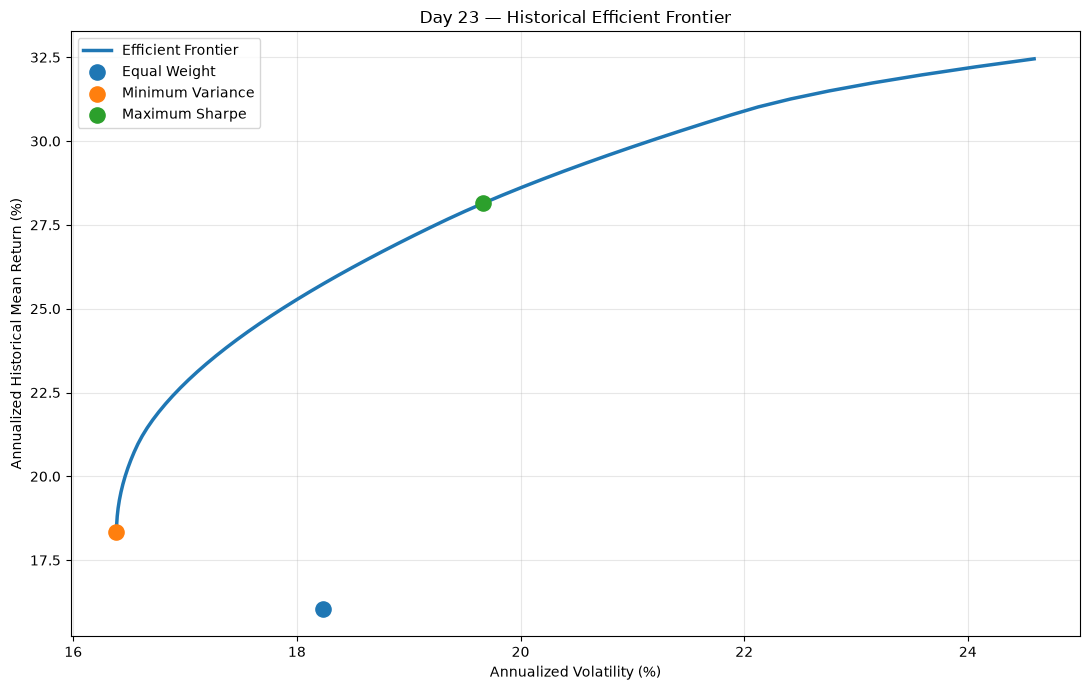

In [10]:

fig, ax = plt.subplots(figsize=(11, 7))

ax.plot(
    frontier["volatility"] * 100,
    frontier["return"] * 100,
    linewidth=2.5,
    label="Efficient Frontier"
)

portfolios = {
    "Equal Weight": initial_weights,
    "Minimum Variance": min_var_result.x,
    "Maximum Sharpe": max_sharpe_result.x
}

for name, weights in portfolios.items():
    ax.scatter(
        portfolio_volatility(weights) * 100,
        portfolio_return(weights) * 100,
        s=120,
        label=name,
        zorder=3
    )

ax.set_title("Day 23 — Historical Efficient Frontier")
ax.set_xlabel("Annualized Volatility (%)")
ax.set_ylabel("Annualized Historical Mean Return (%)")
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

In [11]:

# Day 23 — Portfolio Performance Comparison

portfolios = {
    "Equal Weight": initial_weights,
    "Minimum Variance": min_var_result.x,
    "Maximum Sharpe": max_sharpe_result.x
}

comparison = []

for name, weights in portfolios.items():
    annual_return = portfolio_return(weights)
    annual_volatility = portfolio_volatility(weights)

    sharpe = (
        (annual_return - risk_free_rate) / annual_volatility
        if annual_volatility > 0 else np.nan
    )

    comparison.append({
        "Portfolio": name,
        "Annual Return (%)": annual_return * 100,
        "Annual Volatility (%)": annual_volatility * 100,
        "Sharpe Ratio": sharpe,
        "Largest Position (%)": weights.max() * 100
    })

comparison_df = pd.DataFrame(comparison).set_index("Portfolio")

display(comparison_df.round(2))

,Annual Return (%),Annual Volatility (%),Sharpe Ratio,Largest Position (%)
Portfolio,,,,
Equal Weight,16.04,18.23,0.88,20.00
Minimum Variance,18.33,16.39,1.12,42.05
Maximum Sharpe,28.14,19.66,1.43,66.75


In [12]:

# Day 23 — Out-of-Sample Portfolio Test

split_index = int(len(returns) * 0.70)

train_returns = returns.iloc[:split_index]
test_returns = returns.iloc[split_index:]

train_mu = train_returns.mean().to_numpy() * 252
train_cov = train_returns.cov().to_numpy() * 252

def train_portfolio_return(w):
    return w @ train_mu

def train_portfolio_volatility(w):
    return np.sqrt(w @ train_cov @ w)

def train_negative_sharpe(w):
    vol = train_portfolio_volatility(w)
    if vol <= 0:
        return 1e6
    return -(train_portfolio_return(w) - risk_free_rate) / vol

train_min_var = minimize(
    train_portfolio_volatility,
    initial_weights,
    method="SLSQP",
    bounds=bounds,
    constraints=constraints
)

train_max_sharpe = minimize(
    train_negative_sharpe,
    initial_weights,
    method="SLSQP",
    bounds=bounds,
    constraints=constraints
)

if not train_min_var.success or not train_max_sharpe.success:
    raise RuntimeError("Training optimization failed.")

test_portfolios = {
    "Equal Weight": initial_weights,
    "Minimum Variance": train_min_var.x,
    "Maximum Sharpe": train_max_sharpe.x
}

print("Training observations:", len(train_returns))
print("Testing observations:", len(test_returns))

display(
    pd.DataFrame(
        test_portfolios,
        index=returns.columns
    ).mul(100).round(2)
)

Training observations: 174
Testing observations: 75


,Equal Weight,Minimum Variance,Maximum Sharpe
ticker,,,
AAPL,20.0,37.53,57.51
BLK,20.0,8.94,0.00
GS,20.0,0.00,42.49
JPM,20.0,28.56,0.00
MSFT,20.0,24.97,0.00


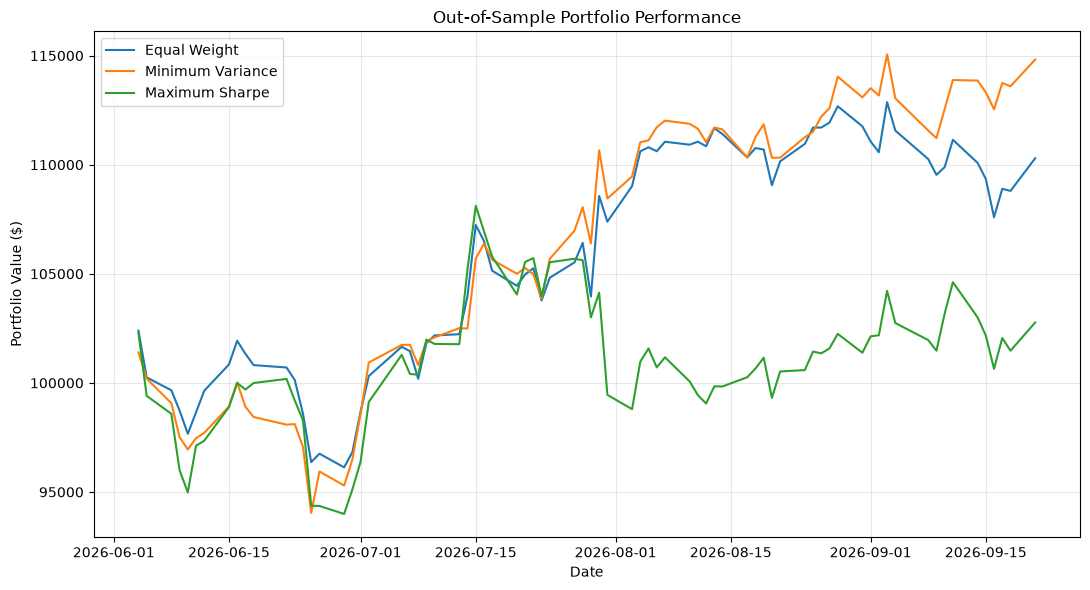

,Test Total Return (%),Annualized Volatility (%),Test Sharpe Ratio
Portfolio,,,
Equal Weight,10.29,19.55,1.78
Minimum Variance,14.82,18.96,2.54
Maximum Sharpe,2.77,23.66,0.50


In [13]:

# Apply fixed training-period allocations to test-period returns.
# This assumes daily rebalancing to maintain constant weights,
# with no transaction costs.

test_portfolio_returns = pd.DataFrame({
    name: test_returns @ weights
    for name, weights in test_portfolios.items()
})

test_equity = (
    100_000 * (1 + test_portfolio_returns).cumprod()
)

fig, ax = plt.subplots(figsize=(11, 6))

for name in test_equity.columns:
    ax.plot(
        test_equity.index,
        test_equity[name],
        label=name
    )

ax.set_title("Out-of-Sample Portfolio Performance")
ax.set_xlabel("Date")
ax.set_ylabel("Portfolio Value ($)")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

test_summary = []

for name in test_portfolio_returns.columns:
    daily = test_portfolio_returns[name]
    annual_return = daily.mean() * 252
    annual_vol = daily.std() * np.sqrt(252)

    test_summary.append({
        "Portfolio": name,
        "Test Total Return (%)": (
            test_equity[name].iloc[-1] / 100_000 - 1
        ) * 100,
        "Annualized Volatility (%)": annual_vol * 100,
        "Test Sharpe Ratio": (
            (annual_return - risk_free_rate) / annual_vol
            if annual_vol > 0 else np.nan
        )
    })

display(
    pd.DataFrame(test_summary)
    .set_index("Portfolio")
    .round(2)
)

In [14]:

print("OUT-OF-SAMPLE PERFORMANCE")
display(
    pd.DataFrame(test_summary)
    .set_index("Portfolio")
    .round(2)
)

print("\nTRAINING-PERIOD ALLOCATIONS (%)")
display(
    pd.DataFrame(
        test_portfolios,
        index=returns.columns
    ).mul(100).round(2)
)

OUT-OF-SAMPLE PERFORMANCE


,Test Total Return (%),Annualized Volatility (%),Test Sharpe Ratio
Portfolio,,,
Equal Weight,10.29,19.55,1.78
Minimum Variance,14.82,18.96,2.54
Maximum Sharpe,2.77,23.66,0.50



TRAINING-PERIOD ALLOCATIONS (%)


,Equal Weight,Minimum Variance,Maximum Sharpe
ticker,,,
AAPL,20.0,37.53,57.51
BLK,20.0,8.94,0.00
GS,20.0,0.00,42.49
JPM,20.0,28.56,0.00
MSFT,20.0,24.97,0.00


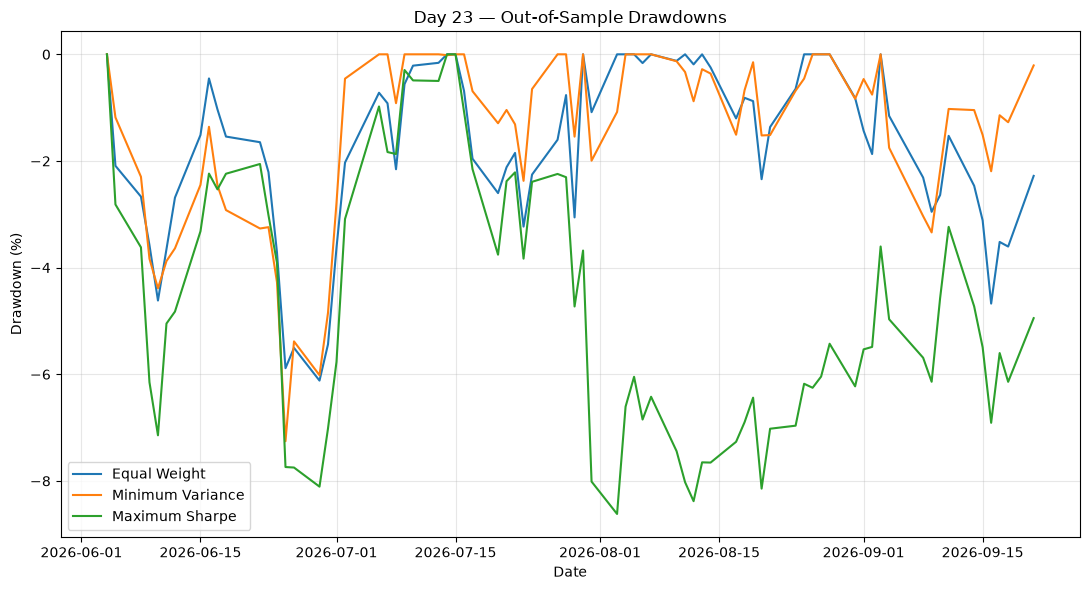

MAXIMUM OUT-OF-SAMPLE DRAWDOWN (%)


,Max Drawdown (%)
Equal Weight,-6.12
Minimum Variance,-7.26
Maximum Sharpe,-8.62


In [15]:

# Calculate drawdowns during the unseen test period

test_running_peak = test_equity.cummax()
test_drawdowns = test_equity / test_running_peak - 1

fig, ax = plt.subplots(figsize=(11, 6))

for name in test_drawdowns.columns:
    ax.plot(
        test_drawdowns.index,
        test_drawdowns[name] * 100,
        label=name
    )

ax.set_title("Day 23 — Out-of-Sample Drawdowns")
ax.set_xlabel("Date")
ax.set_ylabel("Drawdown (%)")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("MAXIMUM OUT-OF-SAMPLE DRAWDOWN (%)")
display(
    (test_drawdowns.min() * 100)
    .to_frame("Max Drawdown (%)")
    .round(2)
)


## Day 23 — Findings and limitations

We compared equal-weight, minimum-variance and
maximum-Sharpe portfolios using five historical stocks.

The portfolios were optimized using the first 70%
of the available observations and evaluated using
the remaining 30%.

### Assumptions
- Long-only portfolios
- Fully invested
- Zero risk-free rate
- Fixed target weights with daily rebalancing
- No dividends or transaction costs modeled
- Historical returns are not future return forecasts

### Limitations
- A relatively short historical sample
- Only five US-listed stocks
- Optimization is sensitive to estimated returns
- A single train/test split
- No economic indicators or fundamental data yet

In [16]:

print("DAY 23 — OUT-OF-SAMPLE PERFORMANCE")
display(
    pd.DataFrame(test_summary)
    .set_index("Portfolio")
    .round(2)
)

print("\nMAXIMUM DRAWDOWN (%)")
display(
    (test_drawdowns.min() * 100)
    .to_frame("Max Drawdown (%)")
    .round(2)
)

print("\nTRAINING-PERIOD ALLOCATIONS (%)")
display(
    pd.DataFrame(
        test_portfolios,
        index=returns.columns
    ).mul(100).round(2)
)

DAY 23 — OUT-OF-SAMPLE PERFORMANCE


,Test Total Return (%),Annualized Volatility (%),Test Sharpe Ratio
Portfolio,,,
Equal Weight,10.29,19.55,1.78
Minimum Variance,14.82,18.96,2.54
Maximum Sharpe,2.77,23.66,0.50



MAXIMUM DRAWDOWN (%)


,Max Drawdown (%)
Equal Weight,-6.12
Minimum Variance,-7.26
Maximum Sharpe,-8.62



TRAINING-PERIOD ALLOCATIONS (%)


,Equal Weight,Minimum Variance,Maximum Sharpe
ticker,,,
AAPL,20.0,37.53,57.51
BLK,20.0,8.94,0.00
GS,20.0,0.00,42.49
JPM,20.0,28.56,0.00
MSFT,20.0,24.97,0.00
